# Lucas-Kanade Feature Tracking

This first part is going to have a lot of visualizations and then I will continue on with the algorithm after. It is not needed to understand how to do this part of the code.

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [29]:
frame_1 = cv2.imread("../data/lucas-kanade-feature-tracking/frames/frame_01.png")
frame_2 = cv2.imread("../data/lucas-kanade-feature-tracking/frames/frame_02.png")

frame_1 = cv2.cvtColor(frame_1, cv2.COLOR_BGR2GRAY)
frame_2 = cv2.cvtColor(frame_2, cv2.COLOR_BGR2GRAY)

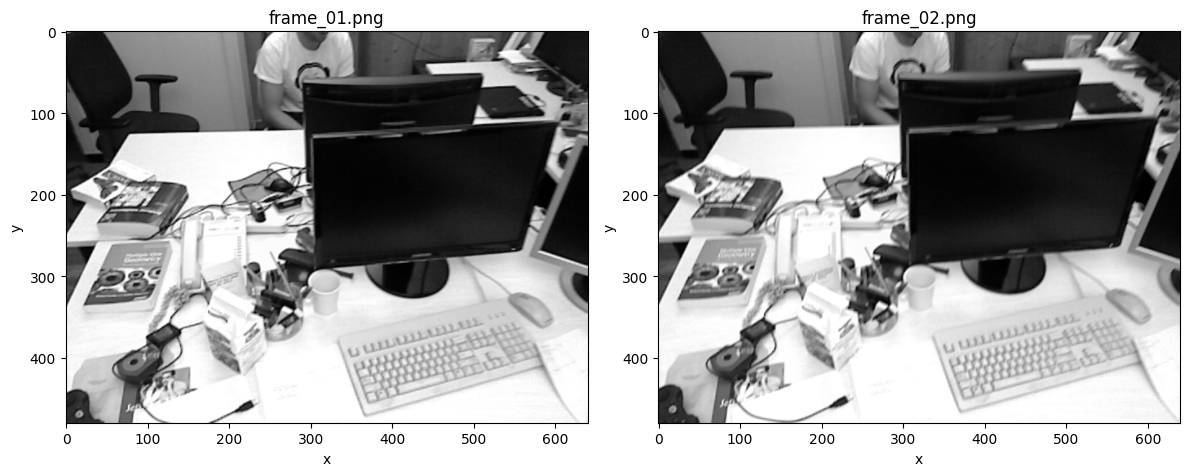

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gray_1, cmap="gray")
axes[0].set_title("frame_01.png")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].imshow(gray_2, cmap="gray")
axes[1].set_title("frame_02.png")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.savefig("../outputs/lucas-kanade-feature-tracking/initial_frames.png", bbox_inches="tight")
plt.show()

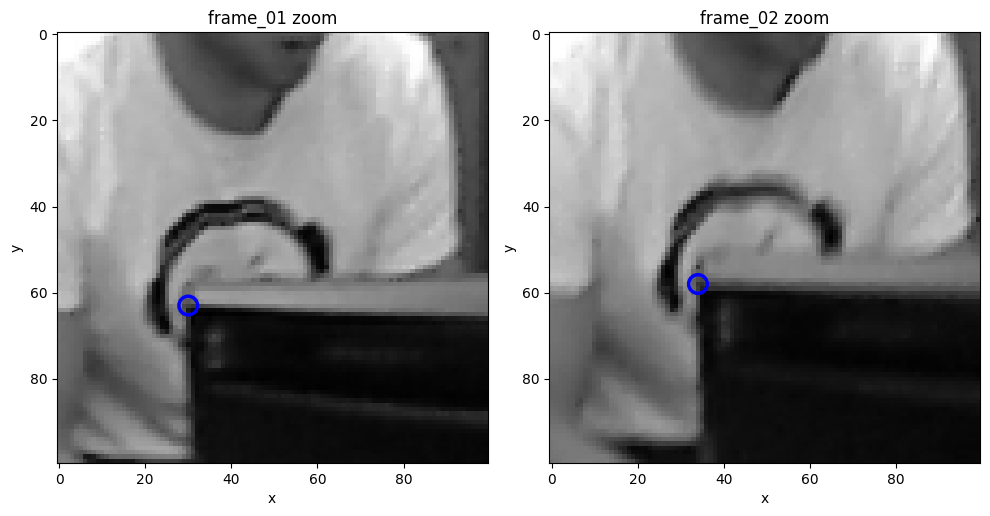

In [31]:
x_center, y_center = 310, 50
patch_size = 100
half_patch = patch_size // 2

x_start = x_center - half_patch
x_end = x_center + half_patch
y_start = y_center - half_patch
y_end = y_center + half_patch

patch_1 = gray_1[y_start:y_end, x_start:x_end]
patch_2 = gray_2[y_start:y_end, x_start:x_end]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(patch_1, cmap="gray")
axes[0].set_title("frame_01 zoom")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].scatter(30, 63, s=180, facecolors="none", edgecolors="blue", linewidths=2.5)

axes[1].imshow(patch_2, cmap="gray")
axes[1].set_title("frame_02 zoom")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].scatter(34, 58, s=180, facecolors="none", edgecolors="blue", linewidths=2.5)

plt.tight_layout()
plt.savefig("../outputs/lucas-kanade-feature-tracking/zoomed_patch_with_points.png", bbox_inches="tight")
plt.show()

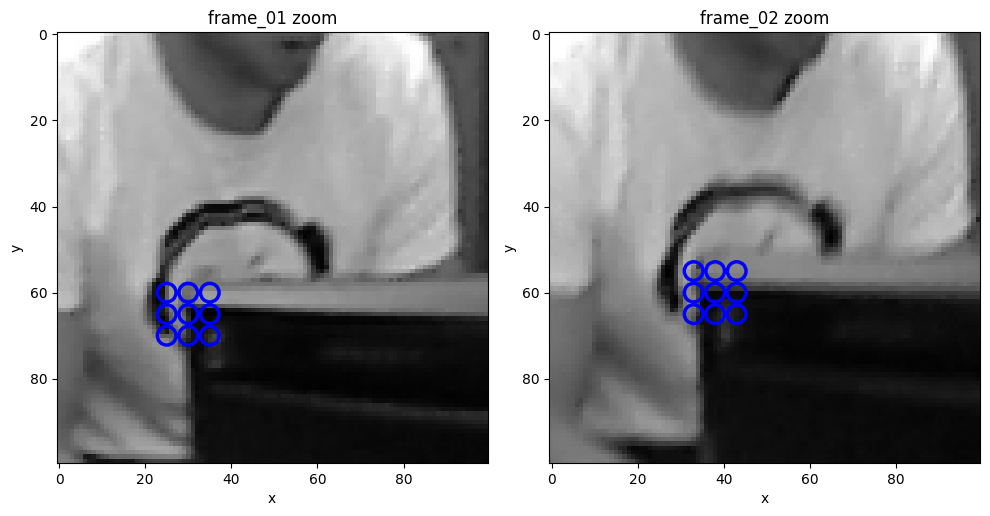

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

frame_1_center = (30, 65)
frame_2_center = (38, 60)

circle_size = 180
circle_linewidth = 2.5
spacing = 5

offsets = [-spacing, 0, spacing]

grid_1_x = []
grid_1_y = []
grid_2_x = []
grid_2_y = []

for dy in offsets:
    for dx in offsets:
        grid_1_x.append(frame_1_center[0] + dx)
        grid_1_y.append(frame_1_center[1] + dy)

        grid_2_x.append(frame_2_center[0] + dx)
        grid_2_y.append(frame_2_center[1] + dy)

axes[0].imshow(patch_1, cmap="gray")
axes[0].set_title("frame_01 zoom")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].scatter(
    grid_1_x,
    grid_1_y,
    s=circle_size,
    facecolors="none",
    edgecolors="blue",
    linewidths=circle_linewidth
)

axes[1].imshow(patch_2, cmap="gray")
axes[1].set_title("frame_02 zoom")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].scatter(
    grid_2_x,
    grid_2_y,
    s=circle_size,
    facecolors="none",
    edgecolors="blue",
    linewidths=circle_linewidth
)

plt.tight_layout()
plt.savefig(
    "../outputs/lucas-kanade-feature-tracking/zoomed_patch_grid_points.png",
    bbox_inches="tight"
)
plt.show()

# Lucas-Kanade Feature Tracking Actual Code

This is where I would really dial into the code and understand everything